<a href="https://colab.research.google.com/github/fikko-nanda/Sistem-Rekomendasi-FILM/blob/main/Kelompok_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Tahap 1: Pengambilan Dataset dan Preprocessing Data**

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd

print("--- 1. Membaca Data Film TMDB via Adapter ---")
# Menembak file utama dari dataset TMDB 2023
file_path_movie = "TMDB_movie_dataset_v11.csv"
df_movies = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "asaniczka/tmdb-movies-dataset-2023-930k-movies/versions/968",
  file_path_movie,
)

# Filter langsung di sini agar RAM aman (ambil film populer dengan vote_count > 100)
df_movies = df_movies[df_movies['vote_count'] > 100].reset_index(drop=True)


print("\n--- 2. Membaca Data Rating via Kagglehub ---")
# Mengunduh data rating pendamping (The Movies Dataset)
path_rating = kagglehub.dataset_download("rounakbanik/the-movies-dataset")

# Membaca ratings_small.csv agar proses SVD nanti cepat dan ringan
df_ratings = pd.read_csv(f"{path_rating}/ratings_small.csv")


print("\n=== BERHASIL LOAD DATA ===")
print(f"Jumlah data film (setelah difilter): {df_movies.shape[0]} baris")
print(f"Jumlah data rating: {df_ratings.shape[0]} baris")
print("\nContoh data film:")
print(df_movies[['id', 'title', 'genres']].head(2))

--- 1. Membaca Data Film TMDB via Adapter ---


/tmp/ipykernel_5754/2354847929.py:8: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_movies = kagglehub.load_dataset(


Using Colab cache for faster access to the 'tmdb-movies-dataset-2023-930k-movies' dataset.

--- 2. Membaca Data Rating via Kagglehub ---
Using Colab cache for faster access to the 'the-movies-dataset' dataset.

=== BERHASIL LOAD DATA ===
Jumlah data film (setelah difilter): 18086 baris
Jumlah data rating: 100004 baris

Contoh data film:
       id         title                              genres
0   27205     Inception  Action, Science Fiction, Adventure
1  157336  Interstellar   Adventure, Drama, Science Fiction


**Visualisasi 1: Analisis Karakteristik Kerapatan Genre Film**


/tmp/ipykernel_5754/3819998463.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='magma')


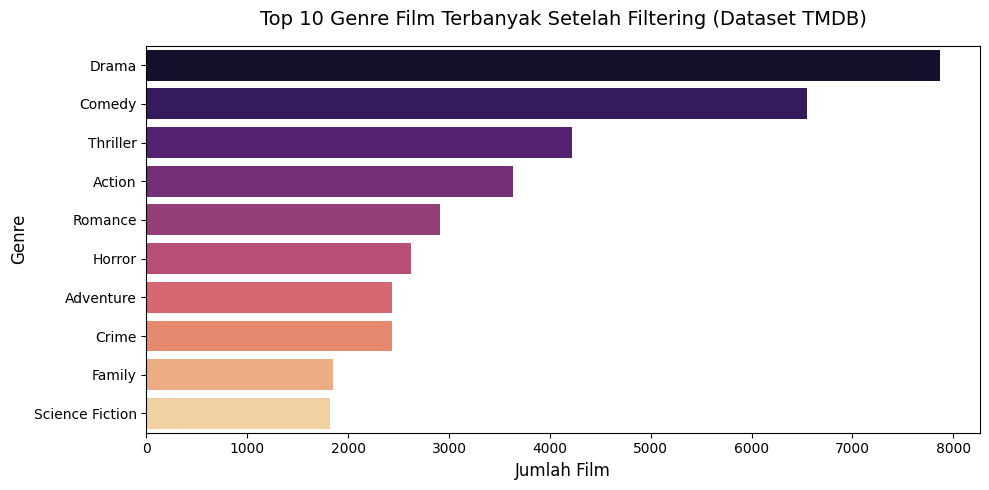

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Memisahkan string genre menjadi list, lalu dihitung kemunculannya
all_genres = df_movies['genres'].str.split(', ').explode()
top_genres = all_genres.value_counts().head(10)

plt.figure(figsize=(10, 5))
# Membuat bar plot dengan seaborn
sns.barplot(x=top_genres.values, y=top_genres.index, palette='magma')

# Menambahkan judul dan label untuk keperluan draf paper
plt.title("Top 10 Genre Film Terbanyak Setelah Filtering (Dataset TMDB)", fontsize=14, pad=15)
plt.xlabel("Jumlah Film", fontsize=12)
plt.ylabel("Genre", fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
!pip install scikit-surprise

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 24.6 MB/s eta 0:00:00


**Tahap 2: Implementasi Algoritma Cascading Hybrid (TF-IDF + Cosine Similarity & SVD)**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from surprise import SVD, Dataset, Reader
from surprise.model_selection import train_test_split
from surprise import accuracy

print("--- [TAHAP 2] MEMBANGUN ENGINE SISTEM REKOMENDASI HYBRID ---")

# 1. Content-Based Filtering Setup
df_movies['genres'] = df_movies['genres'].fillna('')
df_movies = df_movies.reset_index(drop=True)

tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df_movies['genres'])
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print("[OK] TF-IDF dan Cosine Similarity untuk Genre selesai dihitung.")

# 2. Collaborative Filtering Setup (SVD)
reader = Reader(rating_scale=(1, 5))
data_surprise = Dataset.load_from_df(df_ratings[['userId', 'movieId', 'rating']], reader)

trainset, testset = train_test_split(data_surprise, test_size=0.2, random_state=42)
model_svd = SVD(random_state=42)
model_svd.fit(trainset)
print("[OK] Algoritma SVD selesai dilatih menggunakan data rating.")

# Evaluasi Model SVD
predictions = model_svd.test(testset)
rmse_score = accuracy.rmse(predictions)
mae_score = accuracy.mae(predictions)
print(f"Hasil Evaluasi -> RMSE: {rmse_score:.4f} | MAE: {mae_score:.4f}")

# 3. Definisikan Fungsi Hybrid Utama (Dilengkapi Penanganan Cold Start)
def get_hybrid_recommendations_v2(user_id, movie_title, top_n=5):
    try:
        idx = df_movies[df_movies['title'].str.lower() == movie_title.lower()].index[0]
    except IndexError:
        return f"Maaf, film '{movie_title}' tidak ditemukan dalam dataset TMDB."

    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:101]
    movie_indices = [i[0] for i in sim_scores]
    similarity_values = [i[1] for i in sim_scores]

    recommended_movies = df_movies.iloc[movie_indices].copy()
    recommended_movies['similarity_score'] = similarity_values

    is_existing_user = user_id in df_ratings['userId'].values

    if is_existing_user:
        print(f"[LOG SYSTEM] User ID {user_id} ditemukan. Memproses dengan Kombinasi Genre + SVD...")
        preds = []
        for _, row in recommended_movies.iterrows():
            pred_rating = model_svd.predict(user_id, row['id']).est
            preds.append(pred_rating)

        recommended_movies['predicted_rating'] = preds
        recommended_movies['final_hybrid_score'] = (recommended_movies['similarity_score'] * 2.5) + (recommended_movies['predicted_rating'] * 0.5)
        final_recommendations = recommended_movies.sort_values(by='final_hybrid_score', ascending=False)
    else:
        print(f"[LOG SYSTEM] User ID {user_id} tidak terdaftar (User Baru / Cold Start).")
        print("Memproses dengan Fallback Mode: Kombinasi Genre Serupa + Popularitas Global...")
        recommended_movies['final_hybrid_score'] = (recommended_movies['similarity_score'] * 5) + (recommended_movies['vote_average'] / 2)
        final_recommendations = recommended_movies.sort_values(by='final_hybrid_score', ascending=False)

    return final_recommendations[['title', 'genres', 'vote_average', 'final_hybrid_score']].head(top_n)

print("\n=== SYSTEM ENGINE READY TO USE ===")

--- [TAHAP 2] MEMBANGUN ENGINE SISTEM REKOMENDASI HYBRID ---
[OK] TF-IDF dan Cosine Similarity untuk Genre selesai dihitung.
[OK] Algoritma SVD selesai dilatih menggunakan data rating.
RMSE: 0.9023
MAE:  0.6954
Hasil Evaluasi -> RMSE: 0.9023 | MAE: 0.6954

=== SYSTEM ENGINE READY TO USE ===


**Evaluasi Performa Model Collaborative Filtering**

In [ ]:
# ========================================================
# [TAHAP EVALUASI] PENGUJIAN AKURASI MODEL COLLABORATIVE
# ========================================================

print("=== MEMPROSES EVALUASI PERFORMA MODEL (SVD) ===")

# Menguji model dengan 20% data testing yang sudah disiapkan di Tahap 2
predictions = model_svd.test(testset)

# Menghitung standar deviasi error (RMSE) dan rata-rata kesalahan absolut (MAE)
print("\n[HASIL METRIK EVALUASI ACADEMIC]:")
rmse_score = accuracy.rmse(predictions)
mae_score = accuracy.mae(predictions)

print("\n================================================")
print(f"Kesimpulan Nilai Presisi Model SVD:")
print(f"1. Nilai RMSE ({rmse_score:.4f}) -> Mengukur seberapa jauh prediksi menyimpang.")
print(f"2. Nilai MAE ({mae_score:.4f})  -> Rata-rata error tebakan hanya {mae_score:.2f} bintang.")
print("================================================")

=== MEMPROSES EVALUASI PERFORMA MODEL (SVD) ===

[HASIL METRIK EVALUASI ACADEMIC]:
RMSE: 0.9023
MAE:  0.6954

Kesimpulan Nilai Presisi Model SVD:
1. Nilai RMSE (0.9023) -> Mengukur seberapa jauh prediksi menyimpang.
2. Nilai MAE (0.6954)  -> Rata-rata error tebakan hanya 0.70 bintang.


**TAHAP 3: Interaksi Kontrol / Simulasi Input Penguji**


In [ ]:
# ===========================================
# [TAHAP 3] SILAKAN GANTI INPUT DI BAWAH INI
# ===========================================

id_user_input = 10           # Ganti dengan ID user sesukamu (misal: 10, 50, atau 9999 untuk user baru)
judul_film_input = "Inception" # Ganti dengan judul film lain yang ada di dataset

# Memanggil Fungsi Rekomendasi
hasil_rekomendasi = get_hybrid_recommendations_v2(user_id=id_user_input, movie_title=judul_film_input, top_n=5)

print(f"\nHasil Rekomendasi Film Teratas berdasarkan kemiripan dengan '{judul_film_input}':\n")
print(hasil_rekomendasi)

[LOG SYSTEM] User ID 10 ditemukan. Memproses dengan Kombinasi Genre + SVD...

Hasil Rekomendasi Film Teratas berdasarkan kemiripan dengan 'Inception':

                                   title                              genres  \
756                                 Hulk  Science Fiction, Adventure, Action   
49                             Star Wars  Adventure, Action, Science Fiction   
2105                                Tron  Science Fiction, Action, Adventure   
1728                                Dune  Action, Science Fiction, Adventure   
36    Captain America: The First Avenger  Action, Adventure, Science Fiction   

      vote_average  final_hybrid_score  
756          5.500            4.613559  
49           8.204            4.501399  
2105         6.668            4.496723  
1728         6.197            4.341138  
36           6.995            4.326691  


**Visualisasi 2: Top 5 Rekomendasi Akhir Sistem Hybrid**

/tmp/ipykernel_5754/1798232077.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


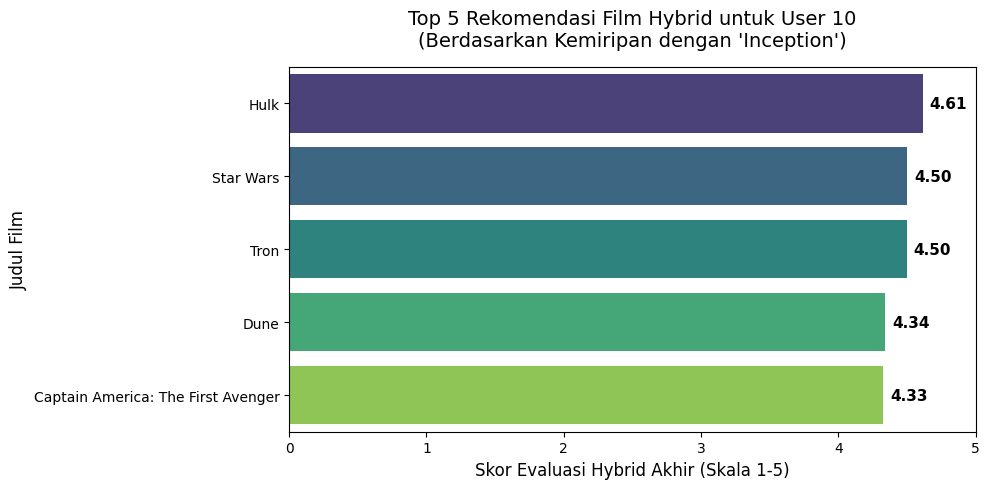

In [ ]:
if isinstance(hasil_rekomendasi, pd.DataFrame):
    plt.figure(figsize=(10, 5))

    # Membuat bar plot mendatar untuk melihat perbandingan skor
    sns.barplot(
        x='final_hybrid_score',
        y='title',
        data=hasil_rekomendasi,
        palette='viridis'
    )

    # Mengatur batas minimum agar perbedaan bar terlihat jelas
    plt.xlim(0, 5)

    # Menambahkan judul dinamis sesuai input user
    plt.title(f"Top 5 Rekomendasi Film Hybrid untuk User {id_user_input}\n(Berdasarkan Kemiripan dengan '{judul_film_input}')", fontsize=14, pad=15)
    plt.xlabel("Skor Evaluasi Hybrid Akhir (Skala 1-5)", fontsize=12)
    plt.ylabel("Judul Film", fontsize=12)

    # Menampilkan nilai angka pastinya di ujung grafik batang
    for index, value in enumerate(hasil_rekomendasi['final_hybrid_score']):
        plt.text(value + 0.05, index, f"{value:.2f}", va='center', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("Pastikan cell Tahap 3 sudah dijalankan dan menghasilkan DataFrame.")

/tmp/ipykernel_5754/3162830554.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df_ratings, palette='Blues_r')


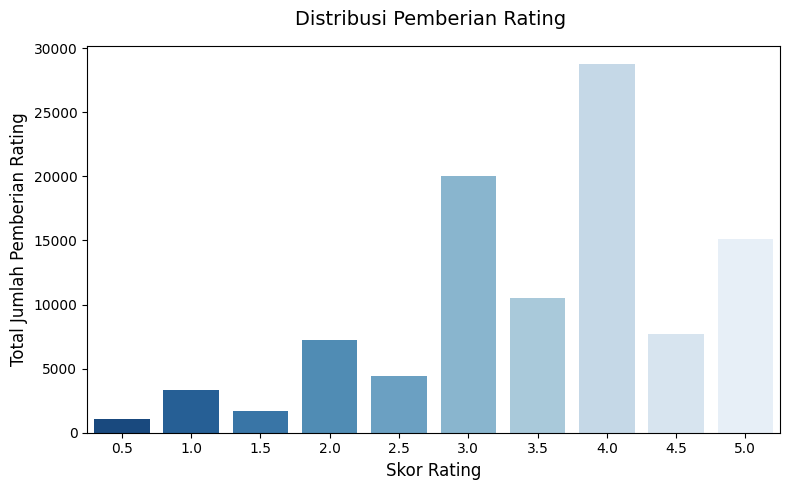

In [ ]:
plt.figure(figsize=(8, 5))

# Membuat grafik countplot untuk distribusi rating
sns.countplot(x='rating', data=df_ratings, palette='Blues_r')

plt.title("Distribusi Pemberian Rating ", fontsize=14, pad=15)
plt.xlabel("Skor Rating", fontsize=12)
plt.ylabel("Total Jumlah Pemberian Rating", fontsize=12)

plt.tight_layout()
plt.show()